# My First Notebook

- Chose to analyze Hepatitis C in Vermont to analyze trends from the opioid epidemic as well as Vermont's current issues with opioid abuse
- Hepatitis C is a stronger indicator of needle sharing than Hepatitis B since C cannot be spread through sexual contact, unlike B. 
data sourced from: https://www.cdc.gov/hepatitis/php/data-research/heptracker/index.html 

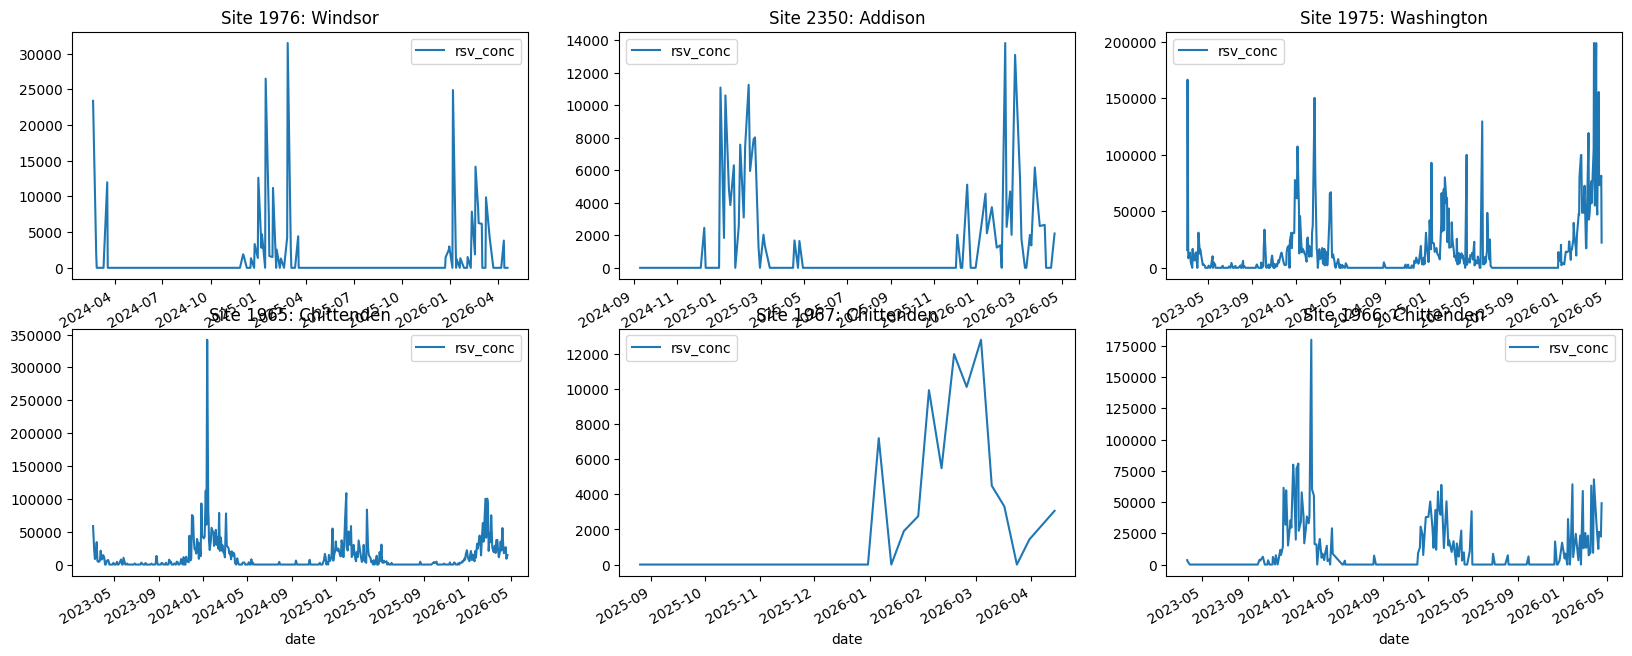

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

data_cleaned = (
    # Read in the CSV
    pd.read_csv("CDC_Wastewater_Data_for_RSV_20260428.csv", 
                usecols = [
                    "site",
                    "state_territory",
                    "counties_served",
                    "sample_collect_date",
                    "pcr_target",
                    "pcr_target_avg_conc"
                ])

    # Filter
    .query("state_territory == 'vt' and pcr_target == 'rsv' and site != 1962")

    # We don't need the pcr_target column anymore, since it is all RSV
    .drop("pcr_target", axis = 1)

    # Rename columns
    .rename(
        columns = {
            "state_territory" : "state",
            "counties_served" : "county",
            "sample_collect_date" : "date",
            "pcr_target_avg_conc" : "rsv_conc" 
        }
    )

    # Change to a datetime
    .assign(date = lambda df: pd.to_datetime(df['date']))#.dt.to_period("M"))

    # Change to a numeric
    .assign(rsv_conc = lambda df: pd.to_numeric(df['rsv_conc'].str.replace(",", ""), errors = 'coerce'))

    # Change to a string
    .assign(site = lambda df: df['site'].astype(str))

    .set_index('date')
    )


# Group by site
groups = data_cleaned.groupby('site', sort = False)

# Store figure and axs returned by subplot func
num_rows = 2
num_cols = int(len(groups) / num_rows)
fig, axs = plt.subplots(num_rows, num_cols, figsize = (20, 8), sharey = False)

for i, (name, group) in enumerate(groups):

    row, col = divmod(i, num_cols)

    # Aggregate by date per site
    group_agg = group.groupby('date')['rsv_conc'].mean()

    # Graph
    group_agg.plot.line(ax = axs[row][col], legend = True)

    axs[row][col].set_title(f"Site {name}: {group['county'].iloc[0]}")



Site 1962 was dropped because no data has been recorded since 8/24. That site serves Bennington

In [25]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

data_cleaned = (
    pd.read_csv("CDC_Wastewater_Viral_Activity_Level_for_Respiratory_Infections.csv")

    # Remove columns
    .drop(["date_updated",
           "Source",
           "Week_End"],
           axis = 1)

    # Rename columns
    .rename(
        columns = {
            "State/Territory" : "state",
            "Counties_Served" : "county",
            "Site_WVAL" : "WVAL",
            "Site_WVAL_Category" : "WVAL_category",
            "Date_Included_In_WVAL" : "date",
            "Pathogen_Target" : "pathogen"
        }
    )

    # Lowercase
    .rename(
        columns = str.lower
    )

    # Filter specific rows
    .query("state == 'Vermont' and pathogen == 'RSV'")

    # Convert dates to periods
    .assign(date = lambda df: pd.to_datetime(df['date']).dt.to_period("M"))

    # Convert wval to numeric
    .assign(wval = lambda df: pd.to_numeric(df['wval'], errors = 'coerce'))

)

groups = data_cleaned.groupby('date')['wval'].mean()

print(groups.reset_index())


      date      wval
0  2023-05  4.384948
1  2024-04  6.219720
2  2024-11  4.016341
3  2025-11  3.552069


Value                           Total       Vermont       
                                Count  Rate   Count   Rate
Year hep_type            Type                             
2011 Acute Hepatitis C   Case    1232   0.4       6    1.0
     Chronic Hepatitis C Case  121556  39.0     618   98.7
2012 Acute Hepatitis C   Case    1778   0.6       6    1.0
     Chronic Hepatitis C Case  127170  40.5     670  107.0
2013 Acute Hepatitis C   Case    2138   0.7       3    0.5


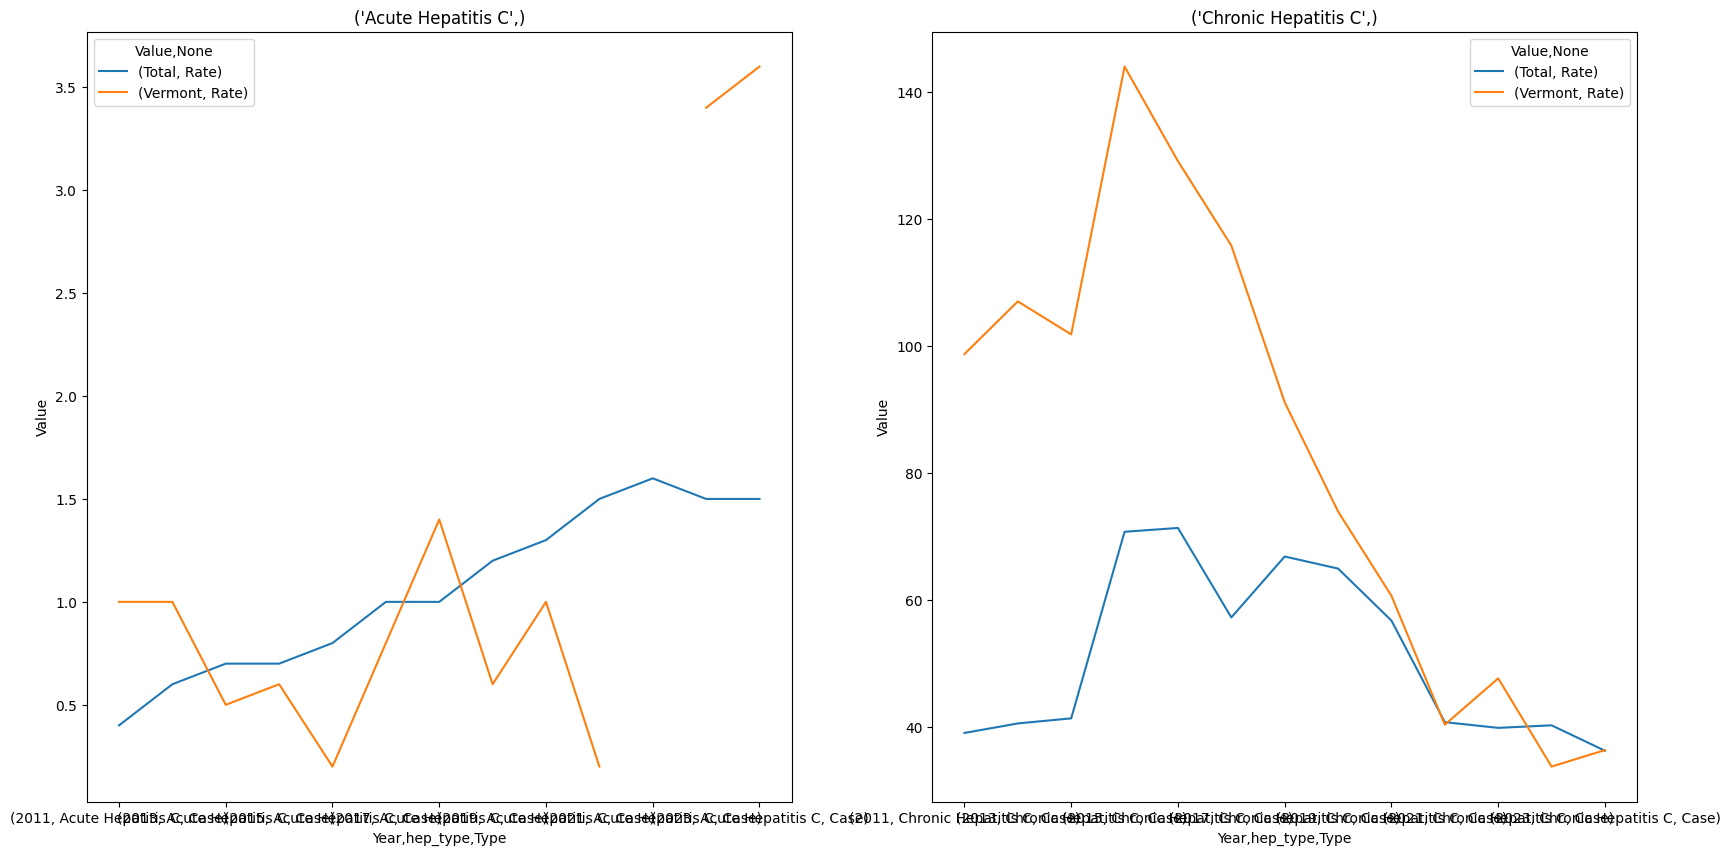

In [41]:
import matplotlib.pyplot as plt
import numpy
import pandas as pd

data_cleaned = (
    # Read the csv file
    pd.read_csv("HepTracker.csv")
    .rename(
        columns = {
            "Event" : "hep_type"

        }
    )

    # Query to filter specific rows
    .query("hep_type.str.contains('Hepatitis C') and " \
    "Character == 'Area' and " \
    "Type == 'Case' and " \
    "Value in ['Vermont', 'Total']")

    # .loc returns the row at the given index. Here I used a lamda function to
    # manually select each row that is able to be changed to a number (this removes
    # the -- (not reported), U (unavailable), N (not reportable), S (suppressed) and
    # UR (unreliable) rows)
    .loc[lambda df: pd.to_numeric(df['Rate'], errors = 'coerce').notna()]

    # Change rates to a numeric column
    .assign(Rate = lambda df: pd.to_numeric(df['Rate'], errors = 'coerce'))

    # Pivot df
    .pivot(index = ["Year", "hep_type", "Type"], columns = "Value", values = ["Rate", "Count"])

    # Swap which is outer and inner label on the y axis
    .swaplevel(0, 1, axis = 1)

    # Sort the indices on the y axis
    .sort_index(axis = 1)
    )

print(data_cleaned.head())

# Group by hepatitis type
groups = data_cleaned.groupby(['hep_type'], sort = False)

# Store figure and axs returned by subplot func
num_rows = 1
num_cols = 2
fig, axs = plt.subplots(num_rows, num_cols, figsize = (20, 10), sharey = False)
#print(axs)

# Loop through each group and create the plot
for i, (name, group) in enumerate(groups):

    col = i

    group.plot.line(ax = axs[col], label = 'Value', legend = True )
    axs[col].set_title(f"{name}")
    axs[col].set_ylabel('Value')

#data_cleaned.plot.bar(x = 'hep_type', y = 'Rate')
